# Part A

In [17]:
# To write a Python 2/3 compatible codebase, the first step is to add this line to the top of each module
from __future__ import division, print_function, unicode_literals

# Two of the main libraries used for scientific computing in Python are imported
# Numpy is the fundamental package for scientific computing with Python.
# SciPy (pronounced "Sigh Pie") is an open source Python library used for scientific computing and technical computing.
import numpy as np # np is an alias pointing to numpy
import scipy as sp # sp is an alias pointing to scipy

# Seed the generator to make this notebook's output stable across runs (the same result every time the code is run, ensuring reproducibility)
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
                                     # matplotlib is a plotting library for the Python programming language
                                     # makes sure that any plots you create are displayed inline in the notebook, below the code cells, instead of in a separate window
import matplotlib                    # the matplotlib library is imported for plotting
import matplotlib.pyplot as plt      # pyplot module is matplotlib's plotting framework https://matplotlib.org/users/pyplot_tutorial.html

# Dynamically change the default rc (runtime configuration) settings in a python script
# See documentation for a complete list of parameters https://matplotlib.org/users/customizing.html
# We change the default rc (runtime configuration) settings (all the plots will have a consistent appearance without having to specify these settings every time)
plt.rcParams['axes.labelsize'] = 14  # fontsize of the x any y labels
plt.rcParams['xtick.labelsize'] = 12 # fontsize of the x tick labels
plt.rcParams['ytick.labelsize'] = 12 # fontsize of the y tick labels

In [18]:
import pandas as pd

data = pd.read_csv("HW1_Data.csv")

data

# Retrieving Attributes
X = data.iloc[:, :-1]

# Retriving Target Variable
y = data.iloc[:, -1]

######################################### Imports #########################################
from sklearn.metrics import confusion_matrix
import itertools
from sklearn.model_selection import train_test_split


###################################### Split the Data ######################################

# Split the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=0)


from sklearn.tree import DecisionTreeClassifier

############################# Build Model & Apply it to the Test Set #######################

# Build the decision tree model

# Initialize classifier
clf3 = DecisionTreeClassifier(criterion='entropy',
                              max_depth=None,
                              random_state=42)

# Fit the classifier to the data
# "clf3.fit(X_train, y_train)" fits the model and then
# ".predict(X_test)" makes predictions based on the test set
y_pred = clf3.fit(X_train, y_train).predict(X_test)

In [19]:
###################################### Confusion Matrix #####################################


# Function that prints and plots the confusion matrix.
# The function provides options to display the matrix as raw counts or normalized values (percentages)
# This function uses matplotlib's functionalities to create a heat map of the confusion matrix and then annotate it with values.
# Normalization can be applied by setting `normalize=True` (see below for examples)
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[2213 1810]
 [1890 2060]]
Normalized confusion matrix
[[0.55 0.45]
 [0.48 0.52]]


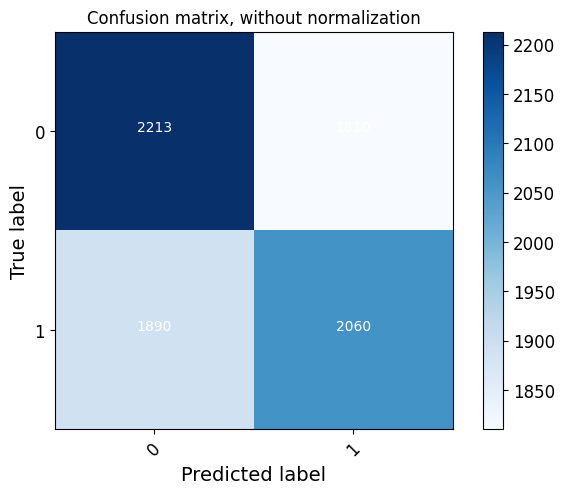

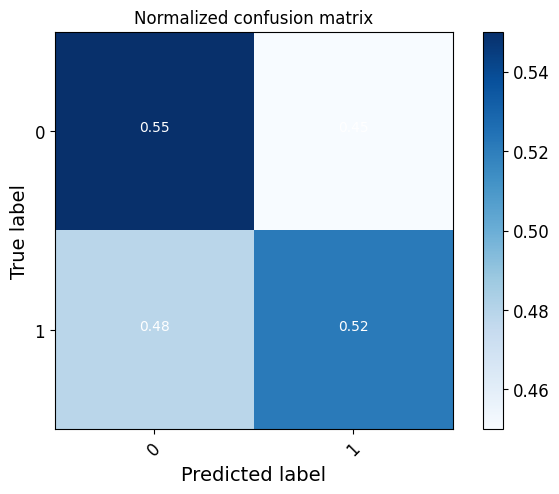

In [20]:
# Compute confusion matrix to evaluate the accuracy of a classification
cnf_matrix = confusion_matrix(y_test, y_pred)

# Determine the way floating point numbers are displayed
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix,
                      classes=['0', '1'],
                      title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix,
                      classes=['0', '1'],
                      normalize=True,
                      title='Normalized confusion matrix')

plt.show()

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [21]:
accuracy = accuracy_score(y_test, y_pred)
classification_error = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_measure = f1_score(y_test, y_pred)

print("Predictive Accuracy:", accuracy)
print("Classification Error:", classification_error)
print("Precision:", precision)
print("Recall:", recall)
print("F-measure:", f_measure)

Predictive Accuracy: 0.5359337764956729
Classification Error: 0.46406622350432714
Precision: 0.5322997416020672
Recall: 0.5215189873417722
F-measure: 0.5268542199488491


*The decision tree model was built using entropy as the splitting criterion with no maximum depth. The dataset was split into training and test sets. On the test set, the model achieved a predictive accuracy of 53.59% and a classification error of 46.41%. The precision was 53.23%, recall was 52.15%, and the F-measure was 52.69%. Overall, the model demonstrates relatively limited predictive performance on the test data.*

## Question 2

In [22]:


############################# Model 2: Entropy, max_depth = 5 #############################

# Initialize classifier
clf_entropy_5 = DecisionTreeClassifier(criterion='entropy',
                                       max_depth=5,
                                       random_state=42)

# Fit the classifier to the data
y_pred_entropy_5 = clf_entropy_5.fit(X_train, y_train).predict(X_test)

accuracy_entropy_5 = accuracy_score(y_test, y_pred_entropy_5)
classification_error_entropy_5 = 1 - accuracy_entropy_5
precision_entropy_5 = precision_score(y_test, y_pred_entropy_5)
recall_entropy_5 = recall_score(y_test, y_pred_entropy_5)
f_measure_entropy_5 = f1_score(y_test, y_pred_entropy_5)

print("Predictive Accuracy:", accuracy_entropy_5)
print("Classification Error:", classification_error_entropy_5)
print("Precision:", precision_entropy_5)
print("Recall:", recall_entropy_5)
print("F-measure:", f_measure_entropy_5)


############################# Model 3: Entropy, max_depth = 10 #############################

# Initialize classifier
clf_entropy_10 = DecisionTreeClassifier(criterion='entropy',
                                        max_depth=10,
                                        random_state=42)

# Fit the classifier to the data
y_pred_entropy_10 = clf_entropy_10.fit(X_train, y_train).predict(X_test)

accuracy_entropy_10 = accuracy_score(y_test, y_pred_entropy_10)
classification_error_entropy_10 = 1 - accuracy_entropy_10
precision_entropy_10 = precision_score(y_test, y_pred_entropy_10)
recall_entropy_10 = recall_score(y_test, y_pred_entropy_10)
f_measure_entropy_10 = f1_score(y_test, y_pred_entropy_10)

print("Predictive Accuracy:", accuracy_entropy_10)
print("Classification Error:", classification_error_entropy_10)
print("Precision:", precision_entropy_10)
print("Recall:", recall_entropy_10)
print("F-measure:", f_measure_entropy_10)


############################# Model 4: Gini Impurity, max_depth = None #############################

# Initialize classifier
clf_gini = DecisionTreeClassifier()

# Fit the classifier to the data
y_pred_gini = clf_gini.fit(X_train, y_train).predict(X_test)

accuracy_gini = accuracy_score(y_test, y_pred_gini)
classification_error_gini = 1 - accuracy_gini
precision_gini = precision_score(y_test, y_pred_gini)
recall_gini = recall_score(y_test, y_pred_gini)
f_measure_gini = f1_score(y_test, y_pred_gini)

print("Predictive Accuracy:", accuracy_gini)
print("Classification Error:", classification_error_gini)
print("Precision:", precision_gini)
print("Recall:", recall_gini)
print("F-measure:", f_measure_gini)


############################# Model 5: Gini Impurity, max_depth = 5 #############################

# Initialize classifier
clf_gini_5 = DecisionTreeClassifier(criterion='gini',
                                    max_depth=5,
                                    random_state=42)

# Fit the classifier to the data
y_pred_gini_5 = clf_gini_5.fit(X_train, y_train).predict(X_test)

accuracy_gini_5 = accuracy_score(y_test, y_pred_gini_5)
classification_error_gini_5 = 1 - accuracy_gini_5
precision_gini_5 = precision_score(y_test, y_pred_gini_5)
recall_gini_5 = recall_score(y_test, y_pred_gini_5)
f_measure_gini_5 = f1_score(y_test, y_pred_gini_5)

print("Predictive Accuracy:", accuracy_gini_5)
print("Classification Error:", classification_error_gini_5)
print("Precision:", precision_gini_5)
print("Recall:", recall_gini_5)
print("F-measure:", f_measure_gini_5)

Predictive Accuracy: 0.5866047911701994
Classification Error: 0.41339520882980063
Precision: 0.5616283452695062
Recall: 0.7544303797468355
F-measure: 0.6439066551426103
Predictive Accuracy: 0.5720556879468205
Classification Error: 0.4279443120531795
Precision: 0.5538215286114446
Recall: 0.7007594936708861
F-measure: 0.6186857398301296
Predictive Accuracy: 0.536560893013922
Classification Error: 0.46343910698607804
Precision: 0.5326003579647149
Recall: 0.5273417721518987
F-measure: 0.5299580206080652
Predictive Accuracy: 0.588987833939546
Classification Error: 0.411012166060454
Precision: 0.5653271209473889
Recall: 0.7372151898734177
F-measure: 0.6399296780573563
